# **Imports**

In [6]:
root = "C:\\Users\\saman\\Documents\\Github\\Magnetic-Levitation\\"

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


from utils.video_analysis import Videos


%load_ext autoreload
%autoreload 2
plt.style.use(root + "style.mplstyle")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **RPM Analysis**

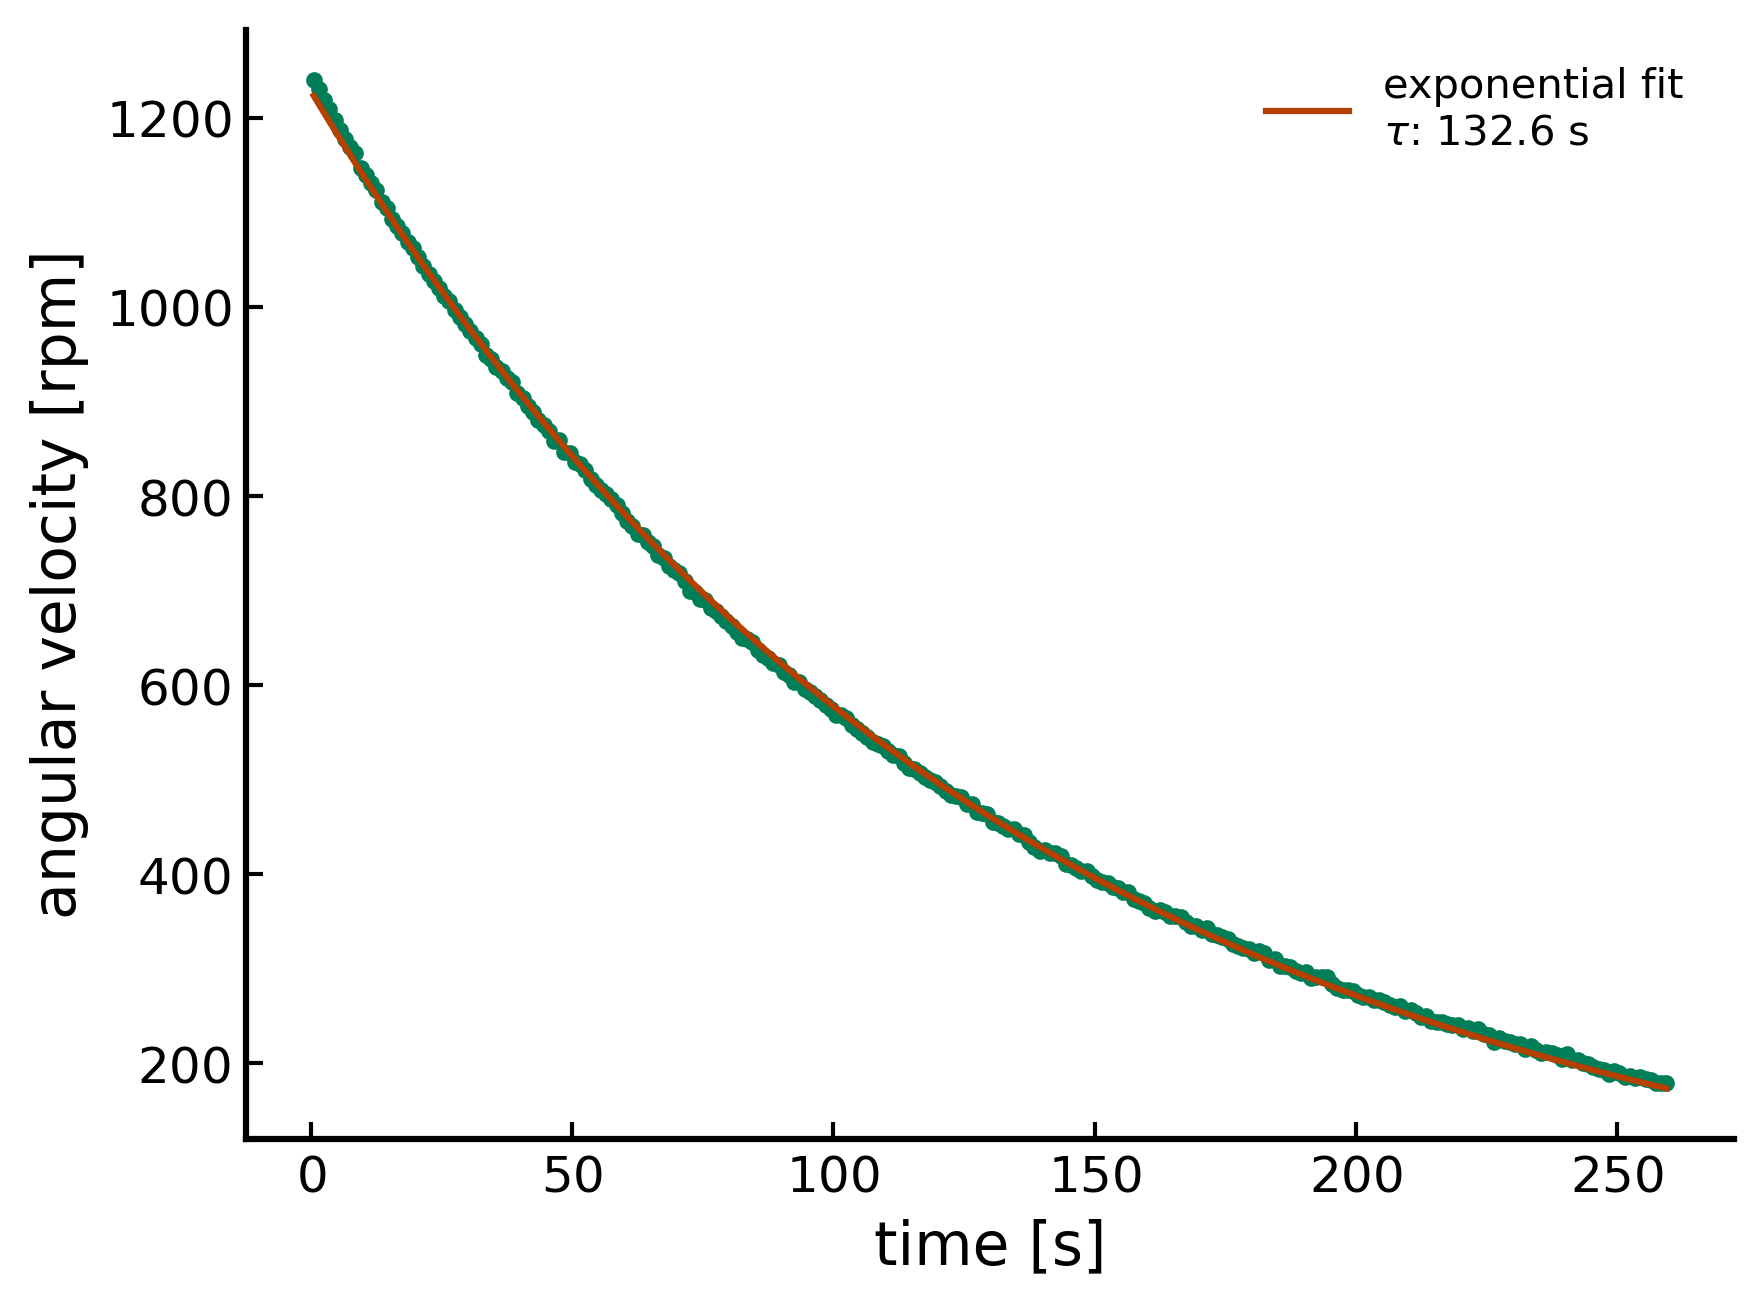

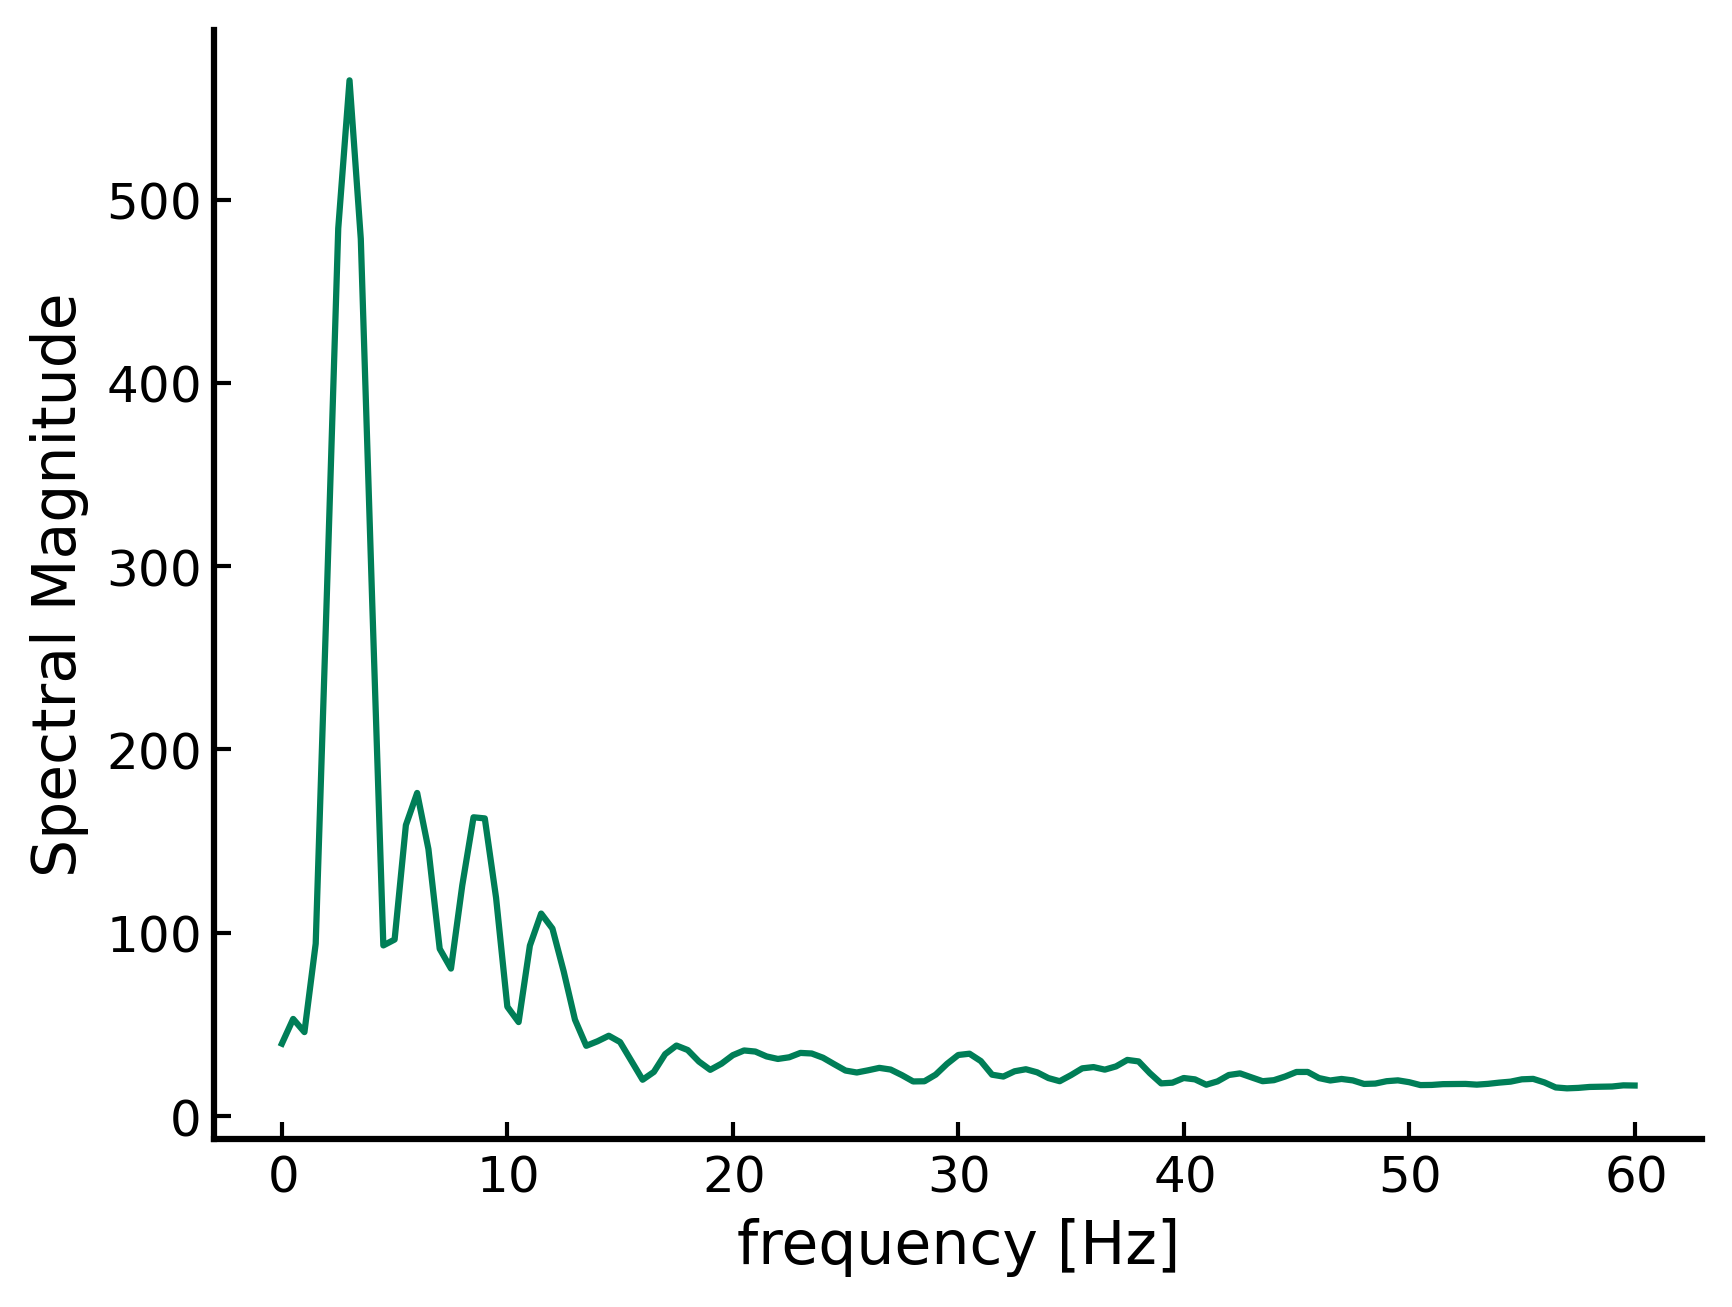

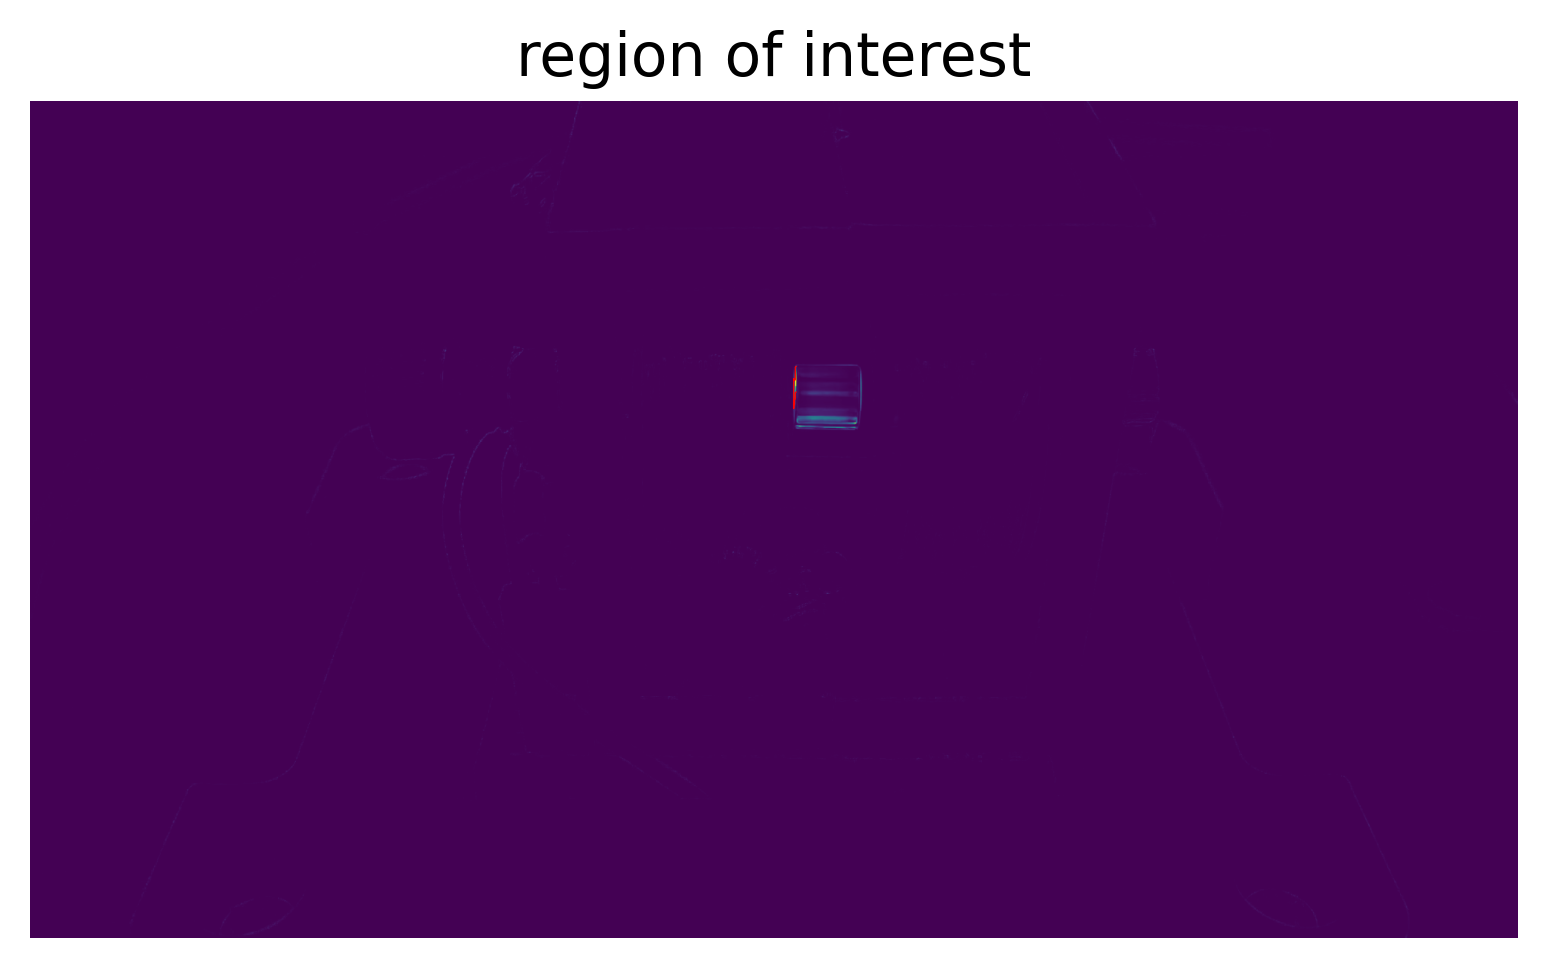

In [48]:
path =  "C:\\Users\\saman\\Documents\\Sensors and Technology Lab\\Magnetic Levitation\\RPM Videos\\"
analyzer = Videos(path)


rpm, fft, frequency, var, outline = analyzer.compute_rpm(path + "IMG_2729.mov", fps = 120)

t = np.arange(len(rpm)) + 0.5
popt, cov = curve_fit(lambda t, a, tau: a*np.exp(-t/tau), t, rpm, p0 = [rpm[0], 1])


plt.plot(t, rpm, linestyle = '', marker = '.')
plt.plot(t, popt[0]*np.exp(-t/popt[1]), label = 'exponential fit \n' + r'$\tau$: ' + f'{popt[1]:.1f} s')
plt.ylabel("angular velocity [rpm]")
plt.xlabel("time [s]")
plt.legend()
plt.show()


plt.plot(frequency, fft)
plt.xlabel("frequency [Hz]")
plt.ylabel("Spectral Magnitude")
plt.show()


plt.imshow(var)
plt.plot(np.squeeze(outline)[:, 0], np.squeeze(outline)[:, 1], linewidth = 0.3, c = 'red')
plt.gca().axes.xaxis.set_ticks([])
plt.gca().axes.yaxis.set_ticks([])
plt.setp(plt.gca().spines.values(), alpha = 0)
plt.title("region of interest")
plt.show()

----